In [2]:
import os
os.chdir('..')  # move up to repo root

import wfdb
import numpy as np
import matplotlib.pyplot as plt

record = wfdb.rdrecord('data/raw/100')
annotation = wfdb.rdann('data/raw/100', 'atr')

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs, "Hz")
print("Signal names:", record.sig_name)
print("Duration:", record.p_signal.shape[0] / record.fs, "seconds")

Signal shape: (650000, 2)
Sampling frequency: 360 Hz
Signal names: ['MLII', 'V5']
Duration: 1805.5555555555557 seconds


In [3]:
print("Total annotations:", len(annotation.sample))
print("First 10 R-peak positions (samples):", annotation.sample[:10])
print("First 10 beat symbols:", annotation.symbol[:10])
print("\nUnique symbols in this record:", set(annotation.symbol))

Total annotations: 2274
First 10 R-peak positions (samples): [  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 beat symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']

Unique symbols in this record: {'V', '+', 'A', 'N'}


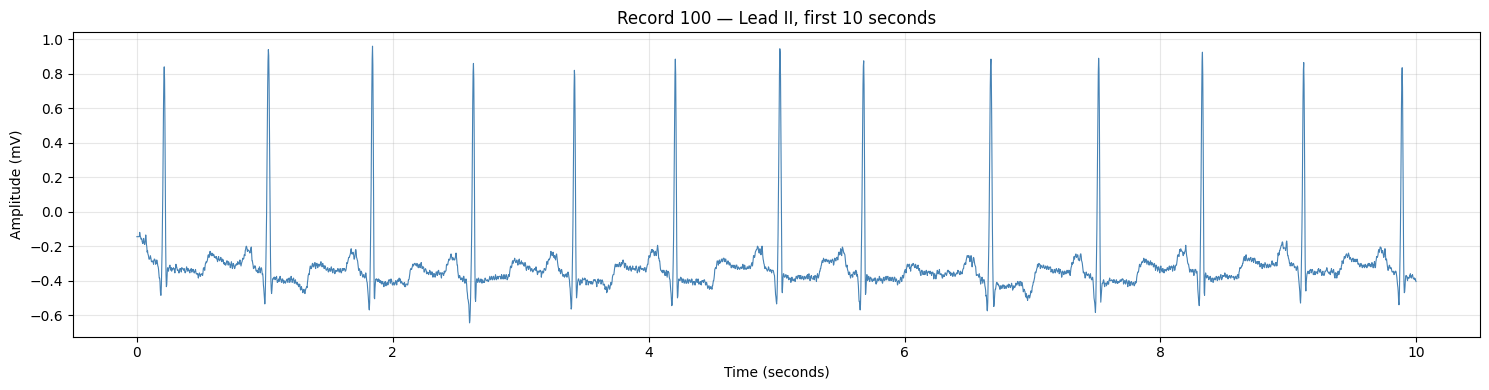

In [4]:
import matplotlib.pyplot as plt

signal = record.p_signal[:, 0]  # Lead II only
fs = record.fs

# Plot first 10 seconds
duration_samples = 10 * fs
t = np.arange(duration_samples) / fs

plt.figure(figsize=(15, 4))
plt.plot(t, signal[:duration_samples], color='steelblue', linewidth=0.8)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.title('Record 100 — Lead II, first 10 seconds')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/raw_ecg.png', dpi=150)
plt.show()

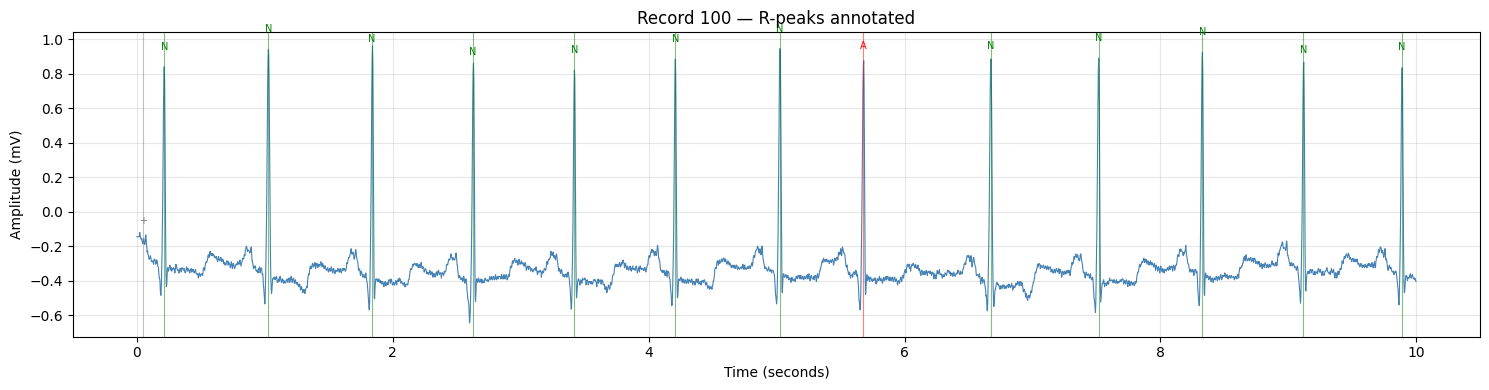

In [5]:
# Plot first 10 seconds with R-peaks marked
duration_samples = 10 * fs
t = np.arange(duration_samples) / fs

# Filter annotations to first 10 seconds
mask = annotation.sample < duration_samples
r_peaks = annotation.sample[mask]
symbols = np.array(annotation.symbol)[mask]

plt.figure(figsize=(15, 4))
plt.plot(t, signal[:duration_samples], color='steelblue', linewidth=0.8)

# Mark each R-peak and label it
colors = {'N': 'green', 'A': 'red', 'V': 'orange', '+': 'gray'}
for peak, sym in zip(r_peaks, symbols):
    color = colors.get(sym, 'black')
    plt.axvline(x=peak/fs, color=color, alpha=0.5, linewidth=0.8)
    plt.text(peak/fs, signal[peak] + 0.1, sym, fontsize=7, color=color, ha='center')

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.title('Record 100 — R-peaks annotated')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/rpeak_annotated.png', dpi=150)
plt.show()

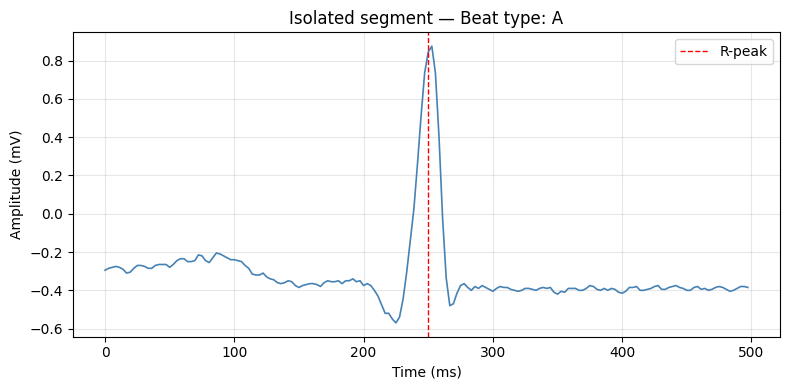

In [6]:
# Pick one beat and plot its isolated segment
half_len = 90
beat_idx = 8  # index 8 is the 'A' beat we saw earlier

peak = annotation.sample[beat_idx]
sym = annotation.symbol[beat_idx]

segment = signal[peak - half_len : peak + half_len]
t_seg = np.arange(len(segment)) / fs * 1000  # convert to milliseconds

plt.figure(figsize=(8, 4))
plt.plot(t_seg, segment, color='steelblue', linewidth=1.2)
plt.axvline(x=half_len/fs*1000, color='red', linestyle='--', linewidth=1, label='R-peak')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (mV)')
plt.title(f'Isolated segment — Beat type: {sym}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/single_segment.png', dpi=150)
plt.show()

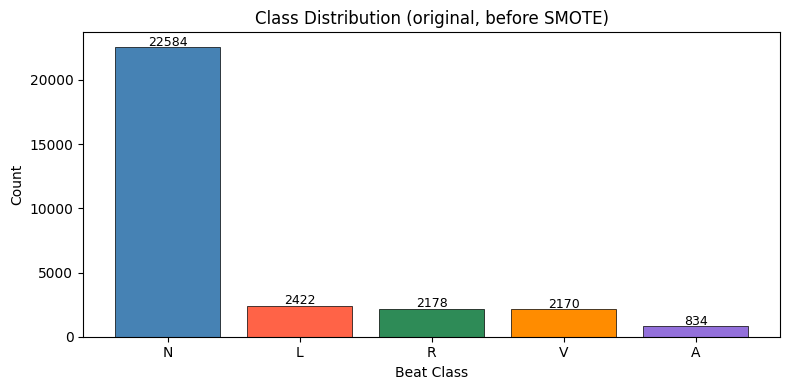

In [7]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt

y_train = np.load('data/processed/y_train.npy')
y_val = np.load('data/processed/y_val.npy')
y_test = np.load('data/processed/y_test.npy')

labels = ['N', 'L', 'R', 'V', 'A']
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

# Before SMOTE = val + test distribution (true distribution)
y_all = np.concatenate([y_val, y_test])
counts = [np.sum(y_all == i) for i in range(5)]

plt.figure(figsize=(8, 4))
plt.bar(labels, counts, color=colors, edgecolor='black', linewidth=0.5)
plt.xlabel('Beat Class')
plt.ylabel('Count')
plt.title('Class Distribution (original, before SMOTE)')
for i, c in enumerate(counts):
    plt.text(i, c + 100, str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('results/figures/class_distribution.png', dpi=150)
plt.show()

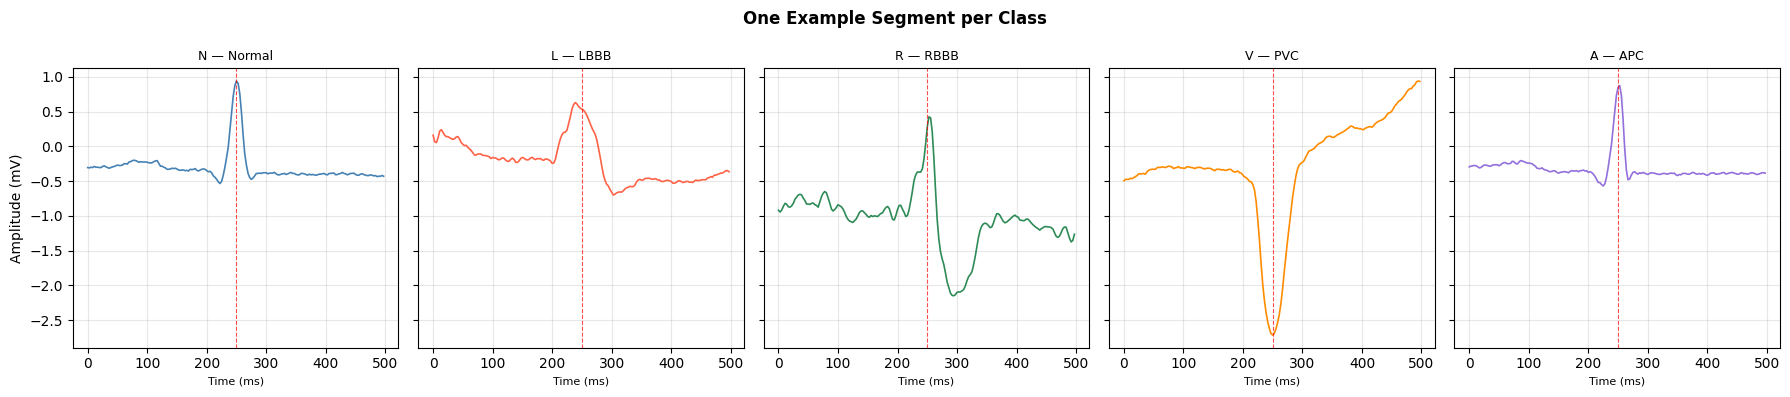

In [8]:
# One example segment per class from the raw data
half_len = 90
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

class_names = {0: 'N — Normal', 1: 'L — LBBB', 2: 'R — RBBB', 3: 'V — PVC', 4: 'A — APC'}
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

# Collect one example per class from raw records
from src.utils.preprocessing import MITBIH_RECORDS, AAMI_MAP, LABEL_TO_IDX
import wfdb

found = {}
for rec_id in MITBIH_RECORDS:
    if len(found) == 5:
        break
    rec_path = f'data/raw/{rec_id}'
    try:
        record = wfdb.rdrecord(rec_path)
        annotation = wfdb.rdann(rec_path, 'atr')
    except:
        continue
    signal = record.p_signal[:, 0]
    for peak, sym in zip(annotation.sample, annotation.symbol):
        if sym not in AAMI_MAP:
            continue
        label = LABEL_TO_IDX[AAMI_MAP[sym]]
        if label in found:
            continue
        start, end = peak - half_len, peak + half_len
        if start < 0 or end > len(signal):
            continue
        found[label] = signal[start:end]

t_ms = np.arange(180) / 360 * 1000  # time axis in milliseconds

for label in range(5):
    ax = axes[label]
    seg = found[label]
    ax.plot(t_ms, seg, color=colors[label], linewidth=1.2)
    ax.axvline(x=90/360*1000, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title(class_names[label], fontsize=9)
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Amplitude (mV)')
fig.suptitle('One Example Segment per Class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/class_examples.png', dpi=150)
plt.show()

There is a clear visibile difference among different classes making this a classification problem.

Only the N and A class have a similar pattern so when model is trained, we might notice a lower F1 score on class A compared to others.

In [9]:
X_test = np.load('data/processed/X_test.npy')
y_test = np.load('data/processed/y_test.npy')

import pandas as pd

class_names = ['N', 'L', 'R', 'V', 'A']
rows = []
for i, name in enumerate(class_names):
    segs = X_test[y_test == i]
    rows.append({
        'Class': name,
        'Count': len(segs),
        'Mean': segs.mean().round(4),
        'Std': segs.std().round(4),
        'Min': segs.min().round(4),
        'Max': segs.max().round(4),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

Class  Count  Mean  Std     Min    Max
    N  11292  -0.0  1.0 -4.8051 6.6157
    L   1211   0.0  1.0 -3.9137 5.6471
    R   1089  -0.0  1.0 -2.9143 5.4023
    V   1085   0.0  1.0 -4.2404 4.2193
    A    417   0.0  1.0 -4.0419 6.6006


Mean ≈ 0 and Std = 1.0 across all classes confirms the z-score normalisation worked correctly on every segment.

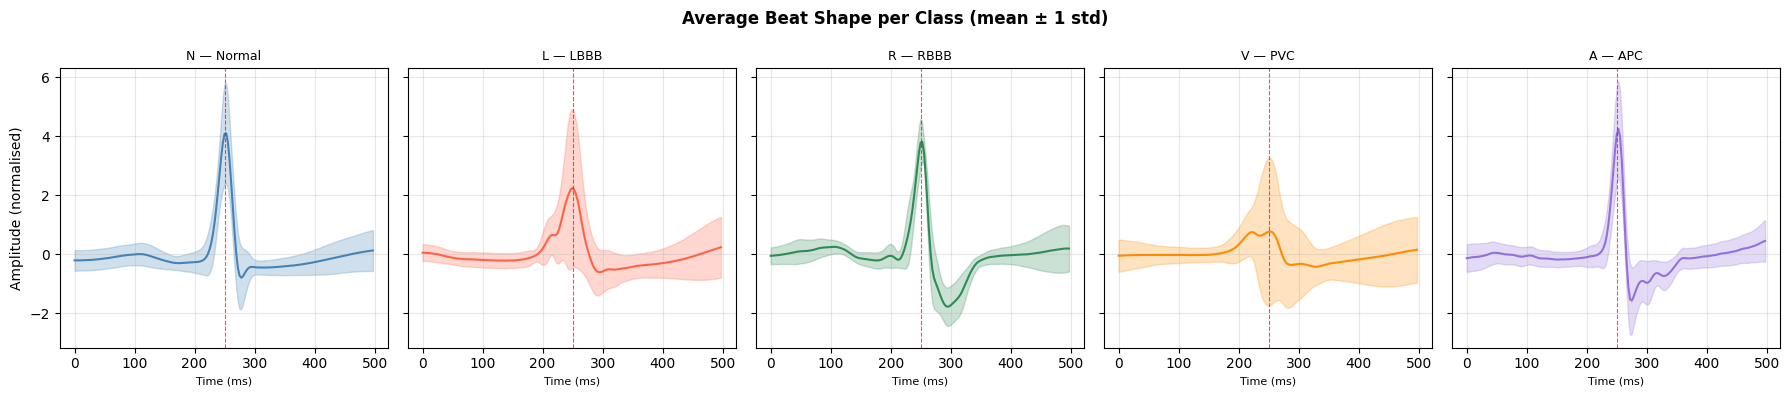

In [10]:
X_test = np.load('data/processed/X_test.npy')
y_test = np.load('data/processed/y_test.npy')

t_ms = np.arange(180) / 360 * 1000
class_names = ['N — Normal', 'L — LBBB', 'R — RBBB', 'V — PVC', 'A — APC']
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for i, (name, color) in enumerate(zip(class_names, colors)):
    segs = X_test[y_test == i]
    mean = segs.mean(axis=0)
    std  = segs.std(axis=0)
    ax = axes[i]
    ax.plot(t_ms, mean, color=color, linewidth=1.5, label='Mean')
    ax.fill_between(t_ms, mean - std, mean + std, alpha=0.25, color=color, label='±1 std')
    ax.axvline(x=90/360*1000, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Amplitude (normalised)')
fig.suptitle('Average Beat Shape per Class (mean ± 1 std)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/average_beat_per_class.png', dpi=150)
plt.show()

There is more variation in classes L and V.

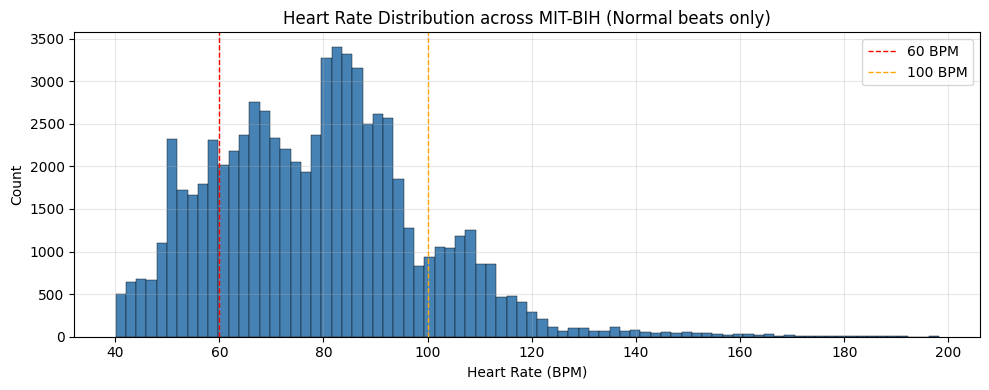

Mean HR: 78.9 BPM
Std HR:  20.1 BPM
Min HR:  40.1 BPM
Max HR:  198.2 BPM


In [11]:
# Heart rate distribution across all 48 records
all_rr_intervals = []

for rec_id in MITBIH_RECORDS:
    rec_path = f'data/raw/{rec_id}'
    try:
        annotation = wfdb.rdann(rec_path, 'atr')
    except:
        continue
    peaks = annotation.sample
    symbols = np.array(annotation.symbol)
    # Only use N beats for clean HR estimate
    normal_peaks = peaks[symbols == 'N']
    if len(normal_peaks) < 2:
        continue
    rr = np.diff(normal_peaks) / 360 * 1000  # convert to milliseconds
    # Filter physiologically plausible RR intervals (300ms–1500ms = 40–200 bpm)
    rr = rr[(rr > 300) & (rr < 1500)]
    all_rr_intervals.extend(rr.tolist())

all_rr = np.array(all_rr_intervals)
hr = 60000 / all_rr  # convert RR interval to BPM

plt.figure(figsize=(10, 4))
plt.hist(hr, bins=80, color='steelblue', edgecolor='black', linewidth=0.3)
plt.xlabel('Heart Rate (BPM)')
plt.ylabel('Count')
plt.title('Heart Rate Distribution across MIT-BIH (Normal beats only)')
plt.axvline(x=60, color='red', linestyle='--', linewidth=1, label='60 BPM')
plt.axvline(x=100, color='orange', linestyle='--', linewidth=1, label='100 BPM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/heart_rate_distribution.png', dpi=150)
plt.show()

print(f"Mean HR: {hr.mean():.1f} BPM")
print(f"Std HR:  {hr.std():.1f} BPM")
print(f"Min HR:  {hr.min():.1f} BPM")
print(f"Max HR:  {hr.max():.1f} BPM")

clearly shows a mix of normal and cardiac patients.